# 4.0 — Comparativa del benchmark y contraste de la hipotesis — Food-101

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/marcoslund/ViT-for-101-food-app/blob/main/notebooks/4.0-comparativa.ipynb)

Junta las corridas de `3.1` a `3.4` y contesta las dos preguntas del proyecto:

1. **¿Cuanto rendimiento se pierde** —si es que se pierde— al usar una arquitectura mas liviana?
2. **¿Donde se concentra esa diferencia**: es pareja entre las 101 clases o se acumula en los platos mas dificiles de distinguir?

No entrena ni evalua nada: lee lo que cada corrida dejo en `reports/results/<modelo>/` (`metrics.json`, predicciones por imagen, reporte por clase, historial) y los artefactos del EDA en `data/processed/`. **No necesita GPU, ni el dataset, ni el extra `deep`.**

- La logica vive en `vit_for_101_food_app/modeling/comparison.py` (con tests en `tests/test_comparison.py`); aca solo se llaman funciones.
- Las diferencias entre modelos se miden **pareadas, imagen por imagen**: todos predijeron exactamente las mismas 25.250 imagenes de test, asi que lo que informa es en cuantas acierta uno y el otro no (IC del 95 % y test exacto de McNemar).

## 0. Antes de ejecutar

Desde la raiz del repo alcanza con las dependencias base:

```bash
uv sync
uv run jupyter lab
```

En **Colab** la celda 0.1 clona el repo e instala el paquete (sin el extra `deep`).

## 0.1 Entorno

In [1]:
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
REPO_BRANCH = "main"

if IN_COLAB:
    REPO_URL = "https://github.com/marcoslund/ViT-for-101-food-app.git"
    REPO_DIR = "/content/ViT-for-101-food-app"
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "-q", "-b", REPO_BRANCH, REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull", "-q"], check=False)
    sys.path.insert(0, REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR], check=True)
    os.chdir(f"{REPO_DIR}/notebooks")

print(f"Colab: {IN_COLAB}")

Colab: False


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from vit_for_101_food_app.config import FIGURES_DIR, REPORTS_DIR
from vit_for_101_food_app.modeling import comparison as cmp

pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

OUT_DIR = REPORTS_DIR / "results" / "comparativa"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

REFERENCIA = cmp.REFERENCE
MODELOS = cmp.available_models()
print("modelos con resultados:", MODELOS)
print("referencia:", REFERENCIA)


def guardar(fig, nombre):
    ruta = FIGURES_DIR / f"comparativa-{nombre}.png"
    fig.savefig(ruta, dpi=150, bbox_inches="tight")
    print("figura:", ruta.relative_to(REPORTS_DIR.parent))

2026-09-27 22:54:21.021 | INFO     | vit_for_101_food_app.config:<module>:11 - PROJ_ROOT path is: /Users/marcoslund/git/ceia/ViT-for-101-food-app/.claude/worktrees/analisis-estado-tp-82eda5


modelos con resultados: ['mobilevit', 'vit', 'swin', 'deit']
referencia: vit


## 1. ¿Son comparables las corridas?

La comparacion solo es entre arquitecturas si todo lo demas es igual. `check_comparable` corta si la receta difiere entre corridas (lr, epocas, batch efectivo, semilla, criterio de seleccion, tamanio de test). `epochs_entrenadas` puede diferir: la define el early stopping.

El entorno se muestra pero no corta: las latencias de la seccion 4 solo son comparables porque las cuatro corridas se midieron en la misma maquina.

In [3]:
metrics = cmp.load_metrics(MODELOS)
cmp.check_comparable(metrics)

,mobilevit,vit,swin,deit
epochs,20,20,20,20
learning_rate,0.0005,0.0005,0.0005,0.0005
weight_decay,0.01,0.01,0.01,0.01
warmup_ratio,0.05,0.05,0.05,0.05
early_stopping_patience,3,3,3,3
metric_for_best,f1_macro,f1_macro,f1_macro,f1_macro
seed,42,42,42,42
batch_efectivo,32,32,32,32
epochs_entrenadas,17.0,20.0,20.0,20.0
n_test,25250,25250,25250,25250


## 2. Tabla comparativa

Una fila por modelo: desempenio sobre el **test completo** (25.250 imagenes) y costo arquitectonico.

- `size_mb_int8_cota` es la cota teorica (fp32 / 4). `size_mb_int8_medido` es el tamanio **real** del modelo cuantizado con cuantizacion dinamica de `nn.Linear`, que es lo que se midio en CPU. Las dos no coinciden cuando el modelo tiene muchas capas que no son `Linear` (convoluciones): es el caso de MobileViT.
- `cpu_int8_ms` es la latencia mediana con batch 1 y un hilo, del modelo cuantizado: lo mas parecido a una medicion del lado del dispositivo que se hizo.

In [4]:
resumen = cmp.summary_table(metrics)
resumen.to_csv(OUT_DIR / "tabla_comparativa.csv")
resumen.drop(columns="checkpoint")

,accuracy,top5_accuracy,f1_macro,params_m,gflops,size_mb_fp32,size_mb_int8_cota,size_mb_int8_medido,cpu_ms,cpu_int8_ms,gpu_ms,epochs_entrenadas,horas_entrenamiento
mobilevit,0.8605,0.9688,0.8609,5.0024,4.0005,19.0825,4.7706,10.8481,105.7017,74.5258,9.7853,17.0,1.6714
vit,0.8239,0.9490,0.8233,85.8763,35.1263,327.5922,81.8980,84.4885,307.4258,200.7379,6.1292,20.0,3.1189
swin,0.8548,0.9664,0.8547,27.5970,8.9798,105.2743,26.3186,26.7229,181.9656,89.1115,29.1606,20.0,1.9403
deit,0.7768,0.9314,0.7765,5.5439,2.5070,21.1483,5.2871,6.0231,50.3848,19.0370,6.4546,20.0,1.0377


## 3. Pregunta 1: ¿cuanto se pierde con un modelo liviano?

Diferencia de accuracy de cada modelo **menos** la referencia (`vit`), sobre las mismas 25.250 imagenes. `solo_a` son las imagenes en que acierta el modelo y falla la referencia; `solo_b`, al reves. Diferencia positiva = el modelo supera a la referencia.

In [5]:
preds = cmp.load_predictions(MODELOS)
dif_ref = cmp.differences_vs(preds, MODELOS, REFERENCIA)
dif_ref.to_csv(OUT_DIR / "diferencias_vs_referencia.csv")
dif_ref

,n,acc_a,acc_b,diff,ic_bajo,ic_alto,solo_a,solo_b,p_mcnemar
mobilevit,25250.0,0.8605,0.8239,0.0366,0.0319,0.0413,2335.0,1411.0,6.6835e-52
swin,25250.0,0.8548,0.8239,0.0309,0.0266,0.0353,1967.0,1186.0,2.6200e-44
deit,25250.0,0.7768,0.8239,-0.0471,-0.0517,-0.0426,1160.0,2350.0,2.4186e-91


Tambien importa la comparacion **entre** los candidatos, que es la decision real para el dispositivo: MobileViT contra Swin (el otro que supera a la referencia) y contra DeiT (el de tamanio parecido).

In [6]:
pares = [("mobilevit", "swin"), ("mobilevit", "deit"), ("swin", "deit")]
entre = pd.DataFrame(
    {f"{a} - {b}": cmp.paired_difference(preds[a], preds[b]) for a, b in pares if a in preds and b in preds}
).T
entre

,n,acc_a,acc_b,diff,ic_bajo,ic_alto,solo_a,solo_b,p_mcnemar
mobilevit - swin,25250.0,0.8605,0.8548,0.0057,0.0013,0.0100,1657.0,1514.0,1.1668e-02
mobilevit - deit,25250.0,0.8605,0.7768,0.0837,0.0786,0.0888,3288.0,1174.0,1.4720e-228
swin - deit,25250.0,0.8548,0.7768,0.0781,0.0734,0.0827,2881.0,910.0,6.6946e-236


## 4. Desempenio contra costo

Un panel por eje de costo (nunca dos escalas en un mismo grafico). La linea punteada une el **frente de Pareto**: los modelos que ningun otro supera a la vez en costo y en F1.

La latencia en **GPU** con batch 1 queda afuera a proposito: con una sola imagen domina el costo fijo de lanzar kernels, y por eso ViT-B (86 M de parametros) sale tan rapido como DeiT-Ti (5,5 M). No dice nada sobre un dispositivo.

figura: reports/figures/comparativa-desempenio-vs-costo.png


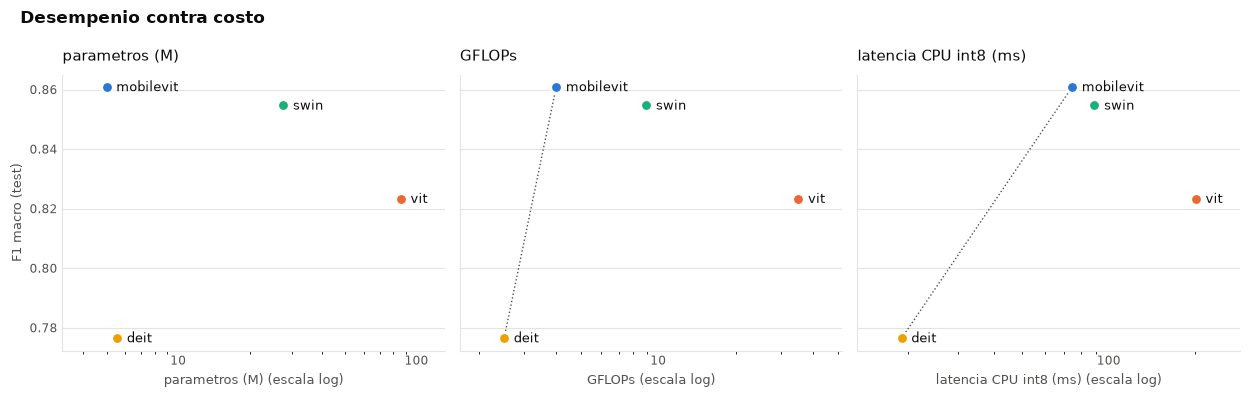

,pareto_params_m,pareto_gflops,pareto_cpu_int8_ms
mobilevit,True,True,True
vit,False,False,False
swin,False,False,False
deit,False,True,True


In [7]:
EJES_COSTO = {
    "params_m": "parametros (M)",
    "gflops": "GFLOPs",
    "cpu_int8_ms": "latencia CPU int8 (ms)",
}
fig = cmp.plot_tradeoff(resumen, EJES_COSTO)
guardar(fig, "desempenio-vs-costo")
plt.show()

pd.concat([cmp.pareto_front(resumen, col) for col in EJES_COSTO], axis=1)

## 5. Pregunta 2: ¿donde se concentra la diferencia?

Cada clase tiene un tercil de dificultad fijado **antes** de entrenar, en el EDA (`class_difficulty.csv`, a partir de la confusion entre clases en el espacio de CLIP). La pregunta es si la brecha contra la referencia es la misma en los tres terciles.

### 5.1 Subset del benchmark (protocolo del EDA)

El subset de 25 imagenes por clase (2.525 en total) es el protocolo que se definio en el EDA; `load_benchmark_subset` verifica su `sha256`. Primero, las metricas por tercil tal como las escribio cada corrida:

In [8]:
subset = cmp.load_benchmark_subset()
dificultad = cmp.load_class_difficulty()

por_tercil = pd.DataFrame(
    {m: {g: v["accuracy"] for g, v in metrics[m]["benchmark_por_tercil"].items()} for m in MODELOS}
).loc[["facil", "medio", "dificil", "subset"]]
por_tercil

,mobilevit,vit,swin,deit
facil,0.9282,0.9082,0.9247,0.8776
medio,0.8752,0.8327,0.8618,0.7818
dificil,0.7824,0.7424,0.7882,0.7047
subset,0.8618,0.8277,0.8582,0.7881


In [9]:
preds_t = cmp.with_tercil(preds, dificultad)

# El tercil del subset y el de class_difficulty tienen que ser el mismo ranking.
control = subset[["rel", "tercil"]].merge(preds_t[["rel", "tercil"]], on="rel", suffixes=("_subset", ""))
assert (control["tercil_subset"] == control["tercil"]).all()

gap_subset = cmp.gap_by_tercil(preds_t[preds_t["rel"].isin(subset["rel"])], MODELOS, REFERENCIA)
gap_subset[["tercil", "modelo", "n", "diff", "ic_bajo", "ic_alto", "p_mcnemar"]]

,tercil,modelo,n,diff,ic_bajo,ic_alto,p_mcnemar
0,facil,mobilevit,850,0.0200,0.0003,0.0397,6.0370e-02
1,facil,swin,850,0.0165,-0.0019,0.0349,1.0342e-01
2,facil,deit,850,-0.0306,-0.0506,-0.0106,3.8362e-03
3,medio,mobilevit,825,0.0424,0.0169,0.0680,1.5572e-03
4,medio,swin,825,0.0291,0.0052,0.0530,2.2298e-02
5,medio,deit,825,-0.0509,-0.0756,-0.0262,7.6928e-05
6,dificil,mobilevit,850,0.0400,0.0088,0.0712,1.4758e-02
7,dificil,swin,850,0.0459,0.0172,0.0746,2.3175e-03
8,dificil,deit,850,-0.0376,-0.0654,-0.0099,1.0056e-02


Con ~850 imagenes por tercil los intervalos son anchos (del orden de ±3 puntos): alcanzan para ver el signo de la brecha, no para comparar su tamanio entre terciles.

### 5.2 Test completo por tercil

El mismo ranking de dificultad aplicado a las 25.250 imagenes de test (~8.500 por tercil). No reemplaza al protocolo del subset: lo complementa con 10 veces mas imagenes y, por lo tanto, intervalos unas 3 veces mas angostos.

figura: reports/figures/comparativa-brecha-por-tercil.png


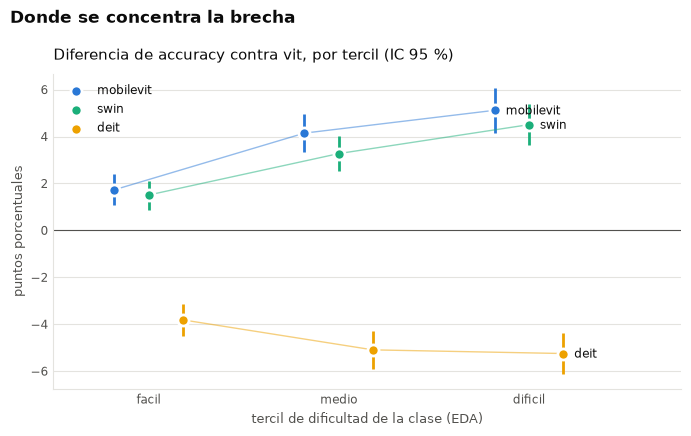

tercil,facil,medio,dificil
modelo,,,
deit,-3.8118,-5.0909,-5.2471
mobilevit,1.7294,4.1455,5.1176
swin,1.5059,3.2727,4.5059


In [10]:
gap_test = cmp.gap_by_tercil(preds_t, MODELOS, REFERENCIA)
gap_test.to_csv(OUT_DIR / "brecha_por_tercil_test.csv", index=False)

fig = cmp.plot_gap_by_tercil(gap_test, REFERENCIA)
guardar(fig, "brecha-por-tercil")
plt.show()

gap_test.pivot(index="modelo", columns="tercil", values="diff")[list(cmp.TERCILES)] * 100

### 5.3 Por clase

El tercil agrupa 34 clases; aca se mira cada una. Para cada clase, F1 del modelo menos F1 de la referencia, contra el **margen** de la clase en el EDA (margen bajo = la clase se parece mucho a su vecina mas cercana = dificil).

`flatness` resume si la brecha es plana: una brecha pareja da un Spearman `rho` cercano a 0. Como el margen crece hacia las clases faciles, un `rho` **negativo** quiere decir que la brecha es mayor en las clases dificiles.

In [11]:
por_clase = cmp.per_class_gap(MODELOS, dificultad, REFERENCIA)
por_clase.to_csv(OUT_DIR / "brecha_por_clase.csv")

planitud = pd.DataFrame([cmp.flatness(por_clase, m) for m in MODELOS if m != REFERENCIA]).set_index("modelo")
planitud

,gap_medio,gap_desvio,clases_gana,clases_pierde,spearman_rho,spearman_p,pendiente
modelo,,,,,,,
mobilevit,0.0375,0.0320,94,7,-0.3252,0.0009,-0.3364
swin,0.0313,0.0260,94,6,-0.3566,0.0003,-0.3191
deit,-0.0468,0.0253,4,97,0.3745,0.0001,0.3034


figura: reports/figures/comparativa-brecha-por-clase-mobilevit.png


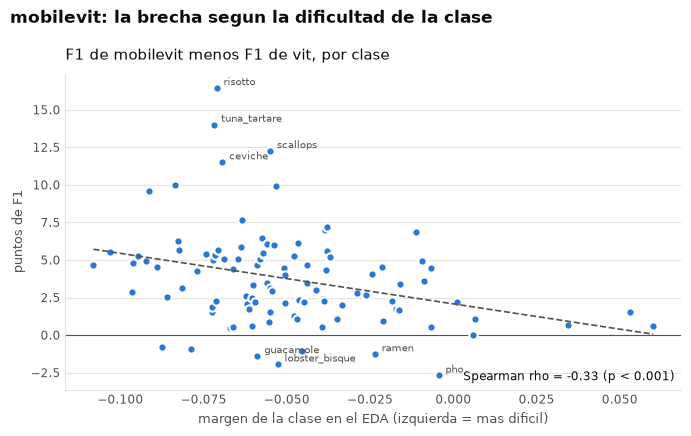

figura: reports/figures/comparativa-brecha-por-clase-swin.png


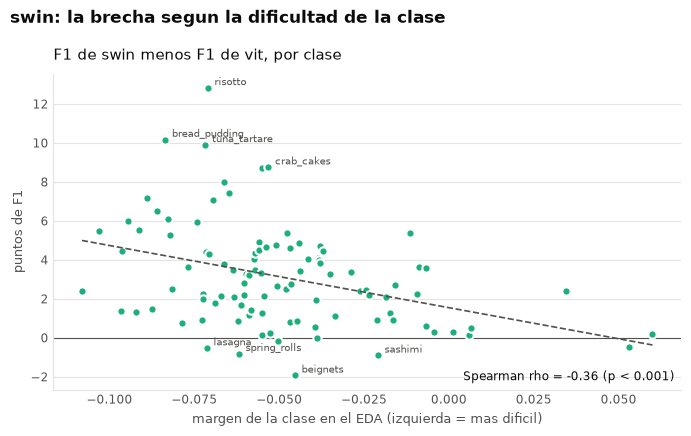

In [12]:
for m in ("mobilevit", "swin"):
    if m in MODELOS:
        fig = cmp.plot_class_gap(por_clase, m, REFERENCIA)
        guardar(fig, f"brecha-por-clase-{m}")
        plt.show()

Las clases donde MobileViT mas gana y mas pierde contra la referencia, con su vecina mas confundible segun el EDA:

In [13]:
cols = ["label", "tercil", "vecino_mas_cercano", "f1_mobilevit", f"f1_{REFERENCIA}", "gap_mobilevit"]
ordenadas = por_clase.sort_values("gap_mobilevit")
display(ordenadas[cols].head(8))
display(ordenadas[cols].tail(8).iloc[::-1])

,label,tercil,vecino_mas_cercano,f1_mobilevit,f1_vit,gap_mobilevit
pho,Pho,facil,Ramen,0.9049,0.9317,-0.0268
lobster_bisque,Lobster bisque,medio,Clam chowder,0.8584,0.8778,-0.0194
guacamole,Guacamole,medio,Nachos,0.9058,0.9197,-0.0139
ramen,Ramen,facil,Pho,0.8834,0.8960,-0.0126
beignets,Beignets,medio,Cannoli,0.8644,0.8748,-0.0104
strawberry_shortcake,Strawberry shortcake,dificil,Cheesecake,0.8611,0.8701,-0.0090
prime_rib,Prime rib,dificil,Steak,0.8502,0.8583,-0.0081
pizza,Pizza,facil,Lasagna,0.8911,0.8907,0.0004


,label,tercil,vecino_mas_cercano,f1_mobilevit,f1_vit,gap_mobilevit
risotto,Risotto,dificil,Gnocchi,0.8178,0.6532,0.1646
tuna_tartare,Tuna tartare,dificil,Beef tartare,0.8176,0.6774,0.1402
scallops,Scallops,medio,Foie gras,0.8195,0.6969,0.1226
ceviche,Ceviche,dificil,Tuna tartare,0.8218,0.7066,0.1152
bread_pudding,Bread pudding,dificil,Apple pie,0.7078,0.6080,0.0998
crab_cakes,Crab cakes,medio,Scallops,0.8251,0.7262,0.0990
chocolate_mousse,Chocolate mousse,dificil,Tiramisu,0.7110,0.6151,0.0959
cannoli,Cannoli,dificil,Beignets,0.9357,0.8588,0.0769


## 6. Validez: ¿que tan firme es el ranking?

Las secciones anteriores comparan **resultados de una receta**, no el techo de cada arquitectura. Tres cosas a tener en cuenta antes de concluir:

**Convergencia.** La receta corta a las 20 epocas. `mejora_ultimas` es cuanto subio el F1 de validacion en las ultimas 3 epocas: si es positiva, la corrida seguia mejorando cuando termino y su resultado es una cota inferior.

figura: reports/figures/comparativa-convergencia.png


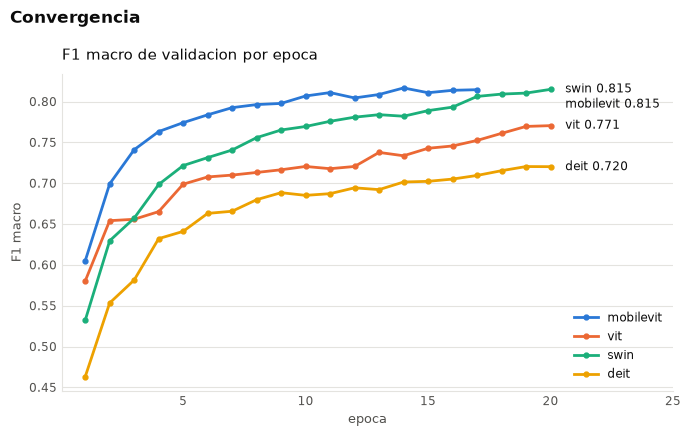

,epocas,mejor_val_f1,epoca_mejor,val_f1_final,mejora_ultimas,val_loss_min,val_loss_final
mobilevit,17.0,0.8167,14.0,0.8145,-0.0021,0.8264,1.0342
vit,20.0,0.7705,20.0,0.7705,0.0181,1.1645,1.3885
swin,20.0,0.8149,20.0,0.8149,0.0086,0.9200,1.2150
deit,20.0,0.7204,19.0,0.7203,0.0107,1.2635,1.5688


In [14]:
historiales = cmp.load_histories(MODELOS)
convergencia = cmp.convergence(historiales)
convergencia.to_csv(OUT_DIR / "convergencia.csv")

fig = cmp.plot_validation_curves(historiales)
guardar(fig, "convergencia")
plt.show()

convergencia

**Receta unica.** Todos los modelos usan `lr = 5e-4`. Es un valor razonable para modelos chicos, pero alto para hacer fine-tuning de ViT-B/16 desde `in21k` (lo habitual esta entre 1e-5 y 1e-4). ViT es el que antes alcanza su perdida de validacion minima (epoca 5, contra 8 o 9 del resto) y tiene una meseta de F1 entre las epocas 6 y 12, consistente con eso. La receta unica es la decision correcta para aislar la arquitectura, pero deja a la referencia en desventaja.

**Validacion contra test.** El F1 de validacion queda unos 4 puntos por debajo del de test en los cuatro modelos. No es una fuga: validacion sale de `train`, que tiene ruido de etiquetas a proposito, y `test` fue curado a mano. Afecta a todos por igual, asi que no cambia el ranking.

**Una sola semilla.** Cada modelo se entreno una vez (seed 42). Los intervalos de las secciones 3 y 5 cubren la variacion por **muestra de imagenes**, no la variacion **entre corridas** de entrenamiento.

In [15]:
val_vs_test = pd.DataFrame(
    {
        "best_val_f1": {m: metrics[m]["best_val_f1_macro"] for m in MODELOS},
        "test_f1": {m: metrics[m]["test"]["f1_macro"] for m in MODELOS},
    }
)
val_vs_test["test - val"] = val_vs_test["test_f1"] - val_vs_test["best_val_f1"]
val_vs_test

,best_val_f1,test_f1,test - val
mobilevit,0.8167,0.8609,0.0442
vit,0.7705,0.8233,0.0528
swin,0.8149,0.8547,0.0397
deit,0.7204,0.7765,0.0561


## 7. Conclusiones

Los numeros de esta seccion son los de la corrida commiteada en `reports/results/`; si se reentrena algun modelo, hay que releerlos contra las tablas de arriba.

**Pregunta 1 — ¿cuanto se pierde?** Con esta receta, **nada: el modelo liviano gana.** MobileViT-S (5,0 M de parametros) supera a ViT-B (86 M) por unos 3,7 puntos de accuracy sobre el test completo (IC 95 % ≈ 3,2 a 4,1; McNemar p < 0,001), con 17 veces menos parametros, 9 veces menos GFLOPs y algo mas de un tercio de la latencia en CPU int8. Swin-T tambien supera a la referencia (≈ +3,1 puntos). DeiT-Ti, de tamanio parecido a MobileViT, es el unico que pierde (≈ −4,7 puntos).

**Pregunta 2 — ¿donde se concentra?** La brecha **no es plana**, pero va en la direccion opuesta a la hipotesis: la ventaja de MobileViT y de Swin sobre ViT **crece** con la dificultad de la clase (test completo: ≈ +1,7 puntos en el tercil facil, +4,2 en el medio, +5,1 en el dificil; Spearman por clase ≈ −0,33). DeiT pierde en los tres terciles, algo mas en los dificiles. Parte de ese patron es un efecto techo: en las clases faciles todos rondan el 90 % y hay menos margen para diferenciarse.

**Recomendacion para el dispositivo.** MobileViT-S esta en el frente de Pareto en los tres ejes de costo y tiene el mejor F1 del benchmark. DeiT-Ti es ≈ 4 veces mas rapido en CPU int8 (19 ms contra 75 ms) y pesa la mitad cuantizado (6 MB contra 11 MB), a cambio de ≈ 8 puntos de accuracy: solo conviene si la latencia es la restriccion dura. Swin-T empata en desempenio con MobileViT, pero cuesta 5,5 veces mas parametros y mas latencia.

**Limites.** El resultado es de **una receta y una semilla**. La referencia no convergio (su F1 de validacion seguia subiendo en la epoca 20) y el lr es alto para ViT-B, asi que su 82 % es una cota inferior de lo que ViT-B puede dar en Food-101. Lo que el benchmark sostiene con firmeza es que **MobileViT no pierde contra la referencia bajo condiciones identicas**; no que la supere en general. Reentrenar ViT con un lr mas bajo es lo que falta para convertir "no pierde" en una brecha medida.

## 8. Artefactos

In [16]:
for p in sorted(OUT_DIR.iterdir()):
    print(" -", p.relative_to(REPORTS_DIR.parent))
for p in sorted(FIGURES_DIR.glob("comparativa-*.png")):
    print(" -", p.relative_to(REPORTS_DIR.parent))

 - reports/results/comparativa/brecha_por_clase.csv
 - reports/results/comparativa/brecha_por_tercil_test.csv
 - reports/results/comparativa/convergencia.csv
 - reports/results/comparativa/diferencias_vs_referencia.csv
 - reports/results/comparativa/tabla_comparativa.csv
 - reports/figures/comparativa-brecha-por-clase-mobilevit.png
 - reports/figures/comparativa-brecha-por-clase-swin.png
 - reports/figures/comparativa-brecha-por-tercil.png
 - reports/figures/comparativa-convergencia.png
 - reports/figures/comparativa-desempenio-vs-costo.png
